# Root locus

In [1]:
import control as ct
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
import sympy as sp

## Define the transfer function $G(s)$

In [2]:
# Open-loop transfer function G(s)
num = [2, -4]
den = [1, 2, 2]
G = ct.tf(num, den)

# Display the transfer function
s = sp.Symbol('s')

num_poly = sum(coef * s**i for i, coef in enumerate(reversed(num)))
den_poly = sum(coef * s**i for i, coef in enumerate(reversed(den)))

latex_standard = sp.latex(num_poly / den_poly)

display(Markdown(f"$$G(s) = {latex_standard}$$"))

$$G(s) = \frac{2 s - 4}{s^{2} + 2 s + 2}$$

The factorized polynomial is:

In [3]:
def factorize_polynomial(poly, symbol):
    p = sp.Poly(poly, symbol)
    lc = p.LC()           # extract the leading coefficient
    roots_dict = sp.roots(p)
    if not roots_dict:
        return sp.latex(poly)
    # reconstruct the factorized form based on their multiplicities
    factors = []
    for root, multiplicity in roots_dict.items():
        for _ in range(multiplicity):
            factors.append(symbol - root)
    factorized_form = sp.Mul(lc, *factors, evaluate=False)
    return sp.latex(factorized_form)


num_decomposed = factorize_polynomial(num_poly, s)
den_decomposed = factorize_polynomial(den_poly, s)

display(Markdown(f"$$G(s) = {latex_standard} = \\frac{{{num_decomposed}}}{{{den_decomposed}}}$$"))

$$G(s) = \frac{2 s - 4}{s^{2} + 2 s + 2} = \frac{2 \left(s - 2\right)}{1 \left(s + 1 + i\right) \left(s + 1 - i\right)}$$

## Draw the root locus

### Asymptotes centroid and angles
The centroid $\sigma_c$ is the intersection of the asymptotes with the real axis, and is calculated as:
$$\sigma_c = \frac{\sum \text{poles} - \sum \text{zeros}}{n - m}$$
where $n$ is the number of poles and $m$ is the number of zeros.

The angles of the asymptotes are given by:
$$\theta_k = \frac{(2k + 1)180^\circ}{n - m}$$
for $k = 0, 1, 2, \ldots, n - m - 1$.

In [4]:
poles = G.poles()
zeros = G.zeros()
n = len(poles)
m = len(zeros)


def format_latex_list(lst):
    if len(lst) == 0:
        return r"\emptyset"
    return ", ".join([str(np.round(p, 2)).replace('j', 'i').strip('()') for p in lst])

# FIX: Keep "\n" as a normal string outside of the raw fr"..." string
output_md = "### Geometric Characteristics of the Root Locus"
output_md += "\n" + fr"- **Poles ($n={n}$):** ${format_latex_list(poles)}$"
output_md += "\n" + fr"- **Zeros ($m={m}$):** ${format_latex_list(zeros)}$"

if n > m:
    sigma_c = (np.sum(poles) - np.sum(zeros)) / (n - m)
    output_md += "\n" + fr"- **Asymptote Centroid:** $\sigma_c = {sigma_c.real:.4f}$"
    output_md += "\n" + fr"- **Asymptote Angles:**"

    for k in range(n - m):
        angle_rad = (2 * k + 1) * np.pi / (n - m)
        angle_deg = np.degrees(angle_rad)
        output_md += "\n" + fr"  * $\theta_{{{k}}} = {angle_deg:.1f}^\circ$ ($\dfrac{{{(2*k+1)}\pi}}{{{n-m}}}$ rad)"

# Render everything beautifully in the notebook
display(Markdown(output_md))

### Geometric Characteristics of the Root Locus
- **Poles ($n=2$):** $-1+1i, -1-1i$
- **Zeros ($m=1$):** $2+0i$
- **Asymptote Centroid:** $\sigma_c = -4.0000$
- **Asymptote Angles:**
  * $\theta_{0} = 180.0^\circ$ ($\dfrac{1\pi}{1}$ rad)

### Breakaway and break-in points
The breakaway and break-in points on the root locus can be found by solving the equation:
$$D(s)N'(s) = D'(s)N(s)$$
where $N(s)$ is the numerator polynomial and $D(s)$ is the denominator polynomial of the open-loop transfer function $G(s)$.
The breakaway points occur where the root locus branches diverge from the real axis, while break-in points occur where they converge back to the real axis.
The points are valid only if the value of the gain $\hat k$ at those points is positive, which can be calculated using:
$$\hat k = -\frac{D(s)}{N(s)} \ge 0$$


In [ ]:
den_polynomial = np.poly1d(den)
num_polynomial = np.poly1d(num)
den_derivative = np.polyder(den_polynomial)
breakaway_candidates = np.roots(den_derivative)
results_md = "\n\n**Calculated Candidates:**\n"
for i, s_val in enumerate(breakaway_candidates):
    # k_hat = -1 / G(s) = -D(s) / N(s)
    k_hat = -np.polyval(den_polynomial, s_val) / np.polyval(num_polynomial, s_val)

    # Format numbers nicely for markdown output
    s_str = str(np.round(s_val, 4)).replace('j', 'i').strip('()')
    k_str = str(np.round(k_hat, 4)).replace('j', 'i').strip('()')

    # A point is valid on the root locus if k_hat is real and positive (> 0)
    is_valid = np.isreal(s_val) and np.isreal(k_hat) and k_hat.real > 0
    status = "😊 **Valid**" if is_valid else "🙁 **Invalid**"

    results_md += f"* Candidate {i+1}: $s = {s_str}$ $\\rightarrow$ $\\hat{{k}} = {k_str}$ ({status})\n"

# Render everything together
display(Markdown(results_md))



**Calculated Candidates:**
* Candidate 1: $s = -1.0$ $\rightarrow$ $\hat{k} = 0.1667$ (✅ **Valid**)


### Intesection with the imaginary axis
To find the intersection of the root locus with the imaginary axis, we can use the Routh-Hurwitz criterion or directly substitute $s = j\omega$ into the characteristic equation and solve for $\omega$ and the corresponding gain $k$.

In [6]:
# Define symbolic variables
# We specify real=True so SymPy knows how to separate Real and Imaginary parts
s = sp.Symbol('s')
K = sp.Symbol('K', real=True)
omega = sp.Symbol('omega', real=True)
char_eq = den_poly + K * num_poly

# Substitute s = j*omega (sp.I represents the imaginary unit 'j')
char_eq_jomega = char_eq.subs(s, sp.I * omega)

# Separate into Real and Imaginary equations
real_part = sp.re(char_eq_jomega)
imag_part = sp.im(char_eq_jomega)

# Solve the system of equations (Real = 0, Imag = 0) for K and omega
raw_solutions = sp.solve([real_part, imag_part], (K, omega))

# Format the results into a beautiful Markdown output
# FIX: Doubled the curly braces around \begin{{cases}} and \end{{cases}}
output_md = "### Imaginary Axis Intersection Analysis\n"
output_md += "By substituting $s = j\\omega$ into the characteristic equation, we solve:\n"
output_md += f"$$D(j\\omega) + K N(j\\omega) = 0 \\rightarrow \\begin{{cases}} \\text{{Real: }} {sp.latex(real_part)} = 0 \\\\ \\text{{Imag: }} {sp.latex(imag_part)} = 0 \\end{{cases}}$$\n\n"

# Normalize solutions format to ensure easy iteration
if isinstance(raw_solutions, dict):
    solutions_list = [(raw_solutions.get(K), raw_solutions.get(omega))]
elif isinstance(raw_solutions, list):
    solutions_list = raw_solutions
else:
    solutions_list = [raw_solutions]

valid_crossings = 0
for sol in solutions_list:
    if isinstance(sol, tuple) and len(sol) == 2:
        K_val, omega_val = sol

        # Filter out purely complex/symbolic evaluation issues safely
        try:
            omega_float = float(omega_val)
            K_float = float(K_val)
        except (TypeError, ValueError):
            continue

        # We look for physical frequencies (omega >= 0)
        if omega_float >= 0:
            valid_crossings += 1
            output_md += f"* **Crossing {valid_crossings}:** At frequency $\\omega = {omega_float:.4f}$ rad/s, the root locus crosses the imaginary axis when the gain is **$K = {K_float:.4f}$**.\n"
            output_md += f"  * Intersection Coordinate: $s = {omega_float:.4f}i$\n"

if valid_crossings == 0:
    output_md += "* **Result:** The root locus branches never cross the imaginary axis for any real value of $K$.\n"

# Render the final presentation block
display(Markdown(output_md))

### Imaginary Axis Intersection Analysis
By substituting $s = j\omega$ into the characteristic equation, we solve:
$$D(j\omega) + K N(j\omega) = 0 \rightarrow \begin{cases} \text{Real: } - 4 K - \omega^{2} + 2 = 0 \\ \text{Imag: } 2 K \omega + 2 \omega = 0 \end{cases}$$

* **Crossing 1:** At frequency $\omega = 2.4495$ rad/s, the root locus crosses the imaginary axis when the gain is **$K = -1.0000$**.
  * Intersection Coordinate: $s = 2.4495i$
* **Crossing 2:** At frequency $\omega = 0.0000$ rad/s, the root locus crosses the imaginary axis when the gain is **$K = 0.5000$**.
  * Intersection Coordinate: $s = 0.0000i$


Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


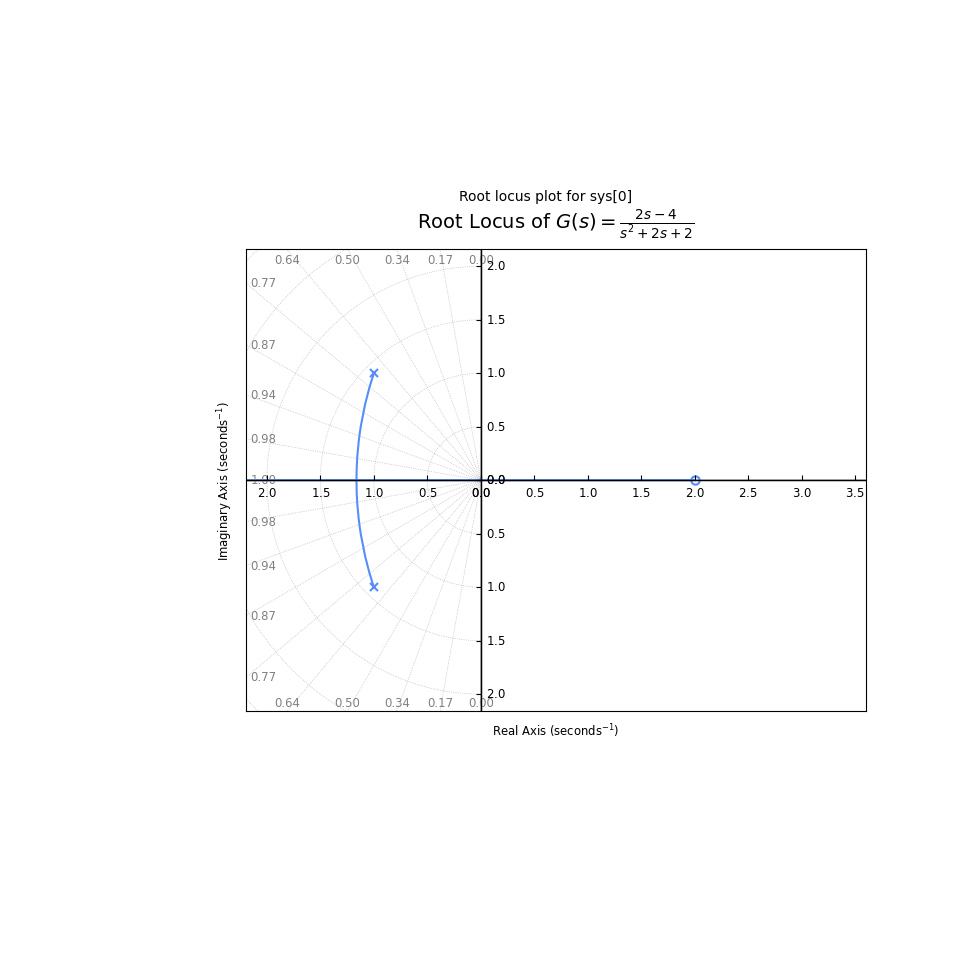

In [7]:
## Plot the root locus
plt.figure(figsize=(8, 6))

# 3. Plot the root locus
# grid=True adds the damping ratio and natural frequency grid lines
ct.root_locus(G, grid=True)

# 4. Customize the appearance
plt.title(fr'Root Locus of $G(s) = {latex_standard}$', fontsize=14, pad=15)
plt.xlabel('Real Axis (seconds$^{-1}$)', fontsize=12)
plt.ylabel('Imaginary Axis (seconds$^{-1}$)', fontsize=12)

plt.axhline(0, color='black', linewidth=1.0)
plt.axvline(0, color='black', linewidth=1.0)

# Display the plot
plt.show()